In [9]:
!pip install torch torchvision pandas matplotlib scikit-learn pillow tqdm


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [13]:
# Décompression train
with zipfile.ZipFile("x_train.zip", 'r') as zip_ref:
    zip_ref.extractall("x_train")

# Décompression test
with zipfile.ZipFile("x_test.zip", 'r') as zip_ref:
    zip_ref.extractall("x_test")

In [14]:
print(os.listdir())

['.config', 'x_test', 'x_test.zip', 'y_test_submission_example_v2.csv', 'x_train.zip', 'drive', 'y_train_v2.csv', 'x_train', 'sample_data']


In [15]:
print("Contenu racine :", os.listdir())
print("Nombre fichiers train :", len(os.listdir("x_train")))
print("Nombre fichiers test :", len(os.listdir("x_test")))

Contenu racine : ['.config', 'x_test', 'x_test.zip', 'y_test_submission_example_v2.csv', 'x_train.zip', 'drive', 'y_train_v2.csv', 'x_train', 'sample_data']
Nombre fichiers train : 9227
Nombre fichiers test : 3955


In [16]:
df = pd.read_csv("y_train_v2.csv")
df.head()

,id,target
0,0,0
1,1,1
2,2,0
3,3,2
4,4,2


In [17]:
print(df.columns)
print(df.shape)
print(df.head())

Index(['id', 'target'], dtype='object')
(9227, 2)
   id  target
0   0       0
1   1       1
2   2       0
3   3       2
4   4       2


In [18]:
def get_label_from_filename(filename):
    # extraire le numéro : img_123.png -> 123
    number = int(filename.split("_")[1].split(".")[0])

    # correspondance CSV (décalage de 1)
    csv_id = number - 1

    # récupérer le label
    return df[df['id'] == csv_id]['target'].values[0]

In [19]:
print(get_label_from_filename("img_1.png"))
print(df.iloc[0]['target'])

0
0


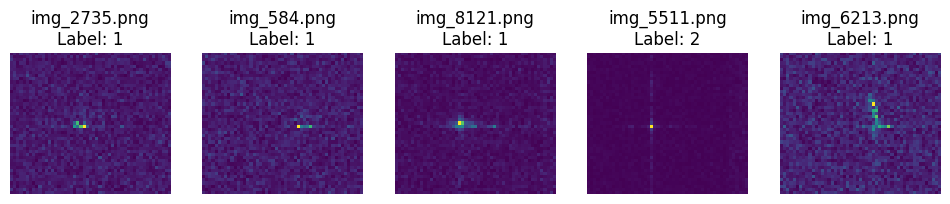

In [20]:
import random

files = os.listdir("x_train")
sample_files = random.sample(files, 5)

plt.figure(figsize=(12,4))

for i, file in enumerate(sample_files):
    img = Image.open(os.path.join("x_train", file))
    label = get_label_from_filename(file)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"{file}\nLabel: {label}")
    plt.axis("off")

plt.show()

In [21]:
img = Image.open(os.path.join("x_train", files[0]))
print(img.size)

(51, 45)


In [22]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split

In [23]:
train_files = os.listdir("x_train")

# tri numérique correct : img_2 avant img_10
train_files = sorted(train_files, key=lambda x: int(x.split("_")[1].split(".")[0]))

print(train_files[:5])
print(train_files[-5:])
print(len(train_files))

['img_1.png', 'img_2.png', 'img_3.png', 'img_4.png', 'img_5.png']
['img_9223.png', 'img_9224.png', 'img_9225.png', 'img_9226.png', 'img_9227.png']
9227


In [24]:
train_labels = [get_label_from_filename(f) for f in train_files]

print(train_files[:5])
print(train_labels[:5])
print(len(train_labels))

['img_1.png', 'img_2.png', 'img_3.png', 'img_4.png', 'img_5.png']
[np.int64(0), np.int64(1), np.int64(0), np.int64(2), np.int64(2)]
9227


In [25]:
import collections

class_counts = collections.Counter(train_labels)
print(class_counts)

Counter({np.int64(1): 3786, np.int64(2): 3002, np.int64(0): 1462, np.int64(3): 977})


In [26]:
train_paths, val_paths, train_targets, val_targets = train_test_split(
    train_files,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

print("Train size :", len(train_paths))
print("Validation size :", len(val_paths))

Train size : 7381
Validation size : 1846


In [27]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(8),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08)
    ),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [28]:
class RadarDataset(Dataset):
    def __init__(self, file_list, labels=None, img_dir="x_train", transform=None):
        self.file_list = file_list
        self.labels = labels
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_name = self.file_list[idx]
        img_path = os.path.join(self.img_dir, file_name)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.labels is not None:
            label = self.labels[idx]
            return image, label
        else:
            return image, file_name

In [29]:
train_dataset = RadarDataset(
    file_list=train_paths,
    labels=train_targets,
    img_dir="x_train",
    transform=train_transform
)

val_dataset = RadarDataset(
    file_list=val_paths,
    labels=val_targets,
    img_dir="x_train",
    transform=val_transform
)

print(len(train_dataset), len(val_dataset))

7381 1846


In [30]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [31]:
images, labels = next(iter(train_loader))

print("Shape images :", images.shape)
print("Shape labels :", labels.shape)
print("Labels batch :", labels[:10])

Shape images : torch.Size([32, 3, 64, 64])
Shape labels : torch.Size([32])
Labels batch : tensor([1, 1, 2, 1, 0, 1, 2, 2, 1, 1])


In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

Device utilisé : cuda


In [33]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))   # 32 -> 16
        x = self.pool(F.relu(self.conv3(x)))   # 16 -> 8

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [36]:
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/10] Train Loss: 1.0993 | Train Acc: 0.5017 | Val Loss: 0.7273 | Val Acc: 0.6885
Epoch [2/10] Train Loss: 0.7217 | Train Acc: 0.6813 | Val Loss: 0.5698 | Val Acc: 0.7346
Epoch [3/10] Train Loss: 0.6085 | Train Acc: 0.7308 | Val Loss: 0.5113 | Val Acc: 0.7763
Epoch [4/10] Train Loss: 0.5415 | Train Acc: 0.7639 | Val Loss: 0.4429 | Val Acc: 0.8099
Epoch [5/10] Train Loss: 0.5079 | Train Acc: 0.7819 | Val Loss: 0.4455 | Val Acc: 0.8218
Epoch [6/10] Train Loss: 0.4813 | Train Acc: 0.8011 | Val Loss: 0.4405 | Val Acc: 0.8088
Epoch [7/10] Train Loss: 0.4415 | Train Acc: 0.8144 | Val Loss: 0.3736 | Val Acc: 0.8516
Epoch [8/10] Train Loss: 0.4142 | Train Acc: 0.8313 | Val Loss: 0.3750 | Val Acc: 0.8554
Epoch [9/10] Train Loss: 0.4011 | Train Acc: 0.8346 | Val Loss: 0.3469 | Val Acc: 0.8673
Epoch [10/10] Train Loss: 0.3851 | Train Acc: 0.8445 | Val Loss: 0.3715 | Val Acc: 0.8651


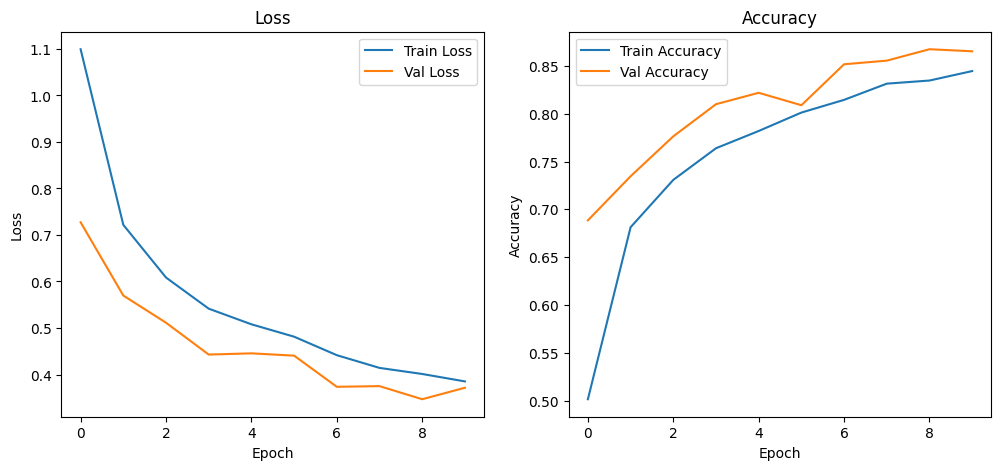

In [37]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.show()

In [38]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)

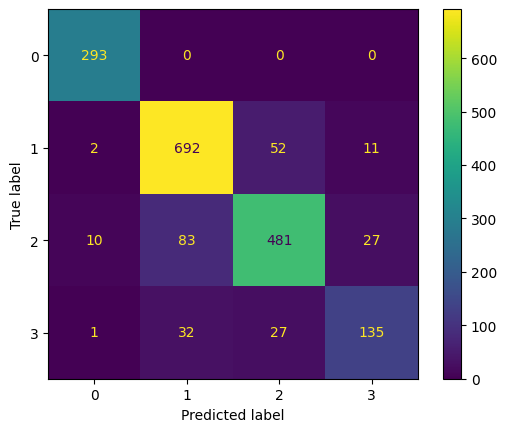

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [40]:
test_files = os.listdir("x_test")
test_files = sorted(test_files, key=lambda x: int(x.split("_")[1].split(".")[0]))

In [41]:
test_dataset = RadarDataset(
    file_list=test_files,
    labels=None,
    img_dir="x_test",
    transform=val_transform
)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [42]:
predictions = []
ids = []

with torch.no_grad():
    for images, filenames in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for file, pred in zip(filenames, preds):
            number = int(file.split("_")[1].split(".")[0])
            csv_id = number - 1

            ids.append(csv_id)
            predictions.append(pred.item())

In [43]:
submission = pd.DataFrame({
    "id": ids,
    "target": predictions
})

submission = submission.sort_values(by="id")
submission.to_csv("submission.csv", index=False)

print(submission.head())

     id  target
0  9227       2
1  9228       2
2  9229       0
3  9230       0
4  9231       1


In [44]:
print(len(submission))

3955


In [45]:
import os
print(os.listdir())

['.config', 'x_test', 'submission.csv', 'best_model.pth', 'x_test.zip', 'y_test_submission_example_v2.csv', 'x_train.zip', 'drive', 'y_train_v2.csv', 'x_train', 'sample_data']


In [46]:
submission.head()

,id,target
0,9227,2
1,9228,2
2,9229,0
3,9230,0
4,9231,1


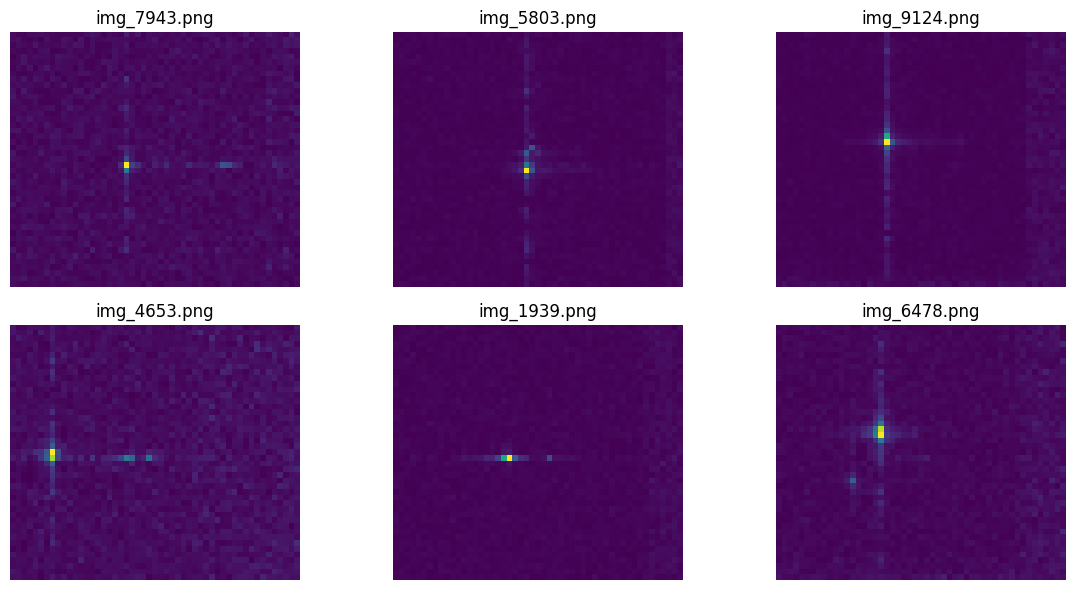

In [47]:
import random

files = os.listdir("x_train")
sample_files = random.sample(files, 6)

plt.figure(figsize=(12,6))

for i, file in enumerate(sample_files):
    img = Image.open(os.path.join("x_train", file))

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [1]:
import os

os.makedirs("project", exist_ok=True)

In [2]:
readme = """# Room Occupancy Classification - MPA MLF 2026

This project aims to classify the number of persons in a room from 60 GHz radar delay-Doppler images.

## Task

The model predicts one of four classes:
- 0: no person
- 1: one person
- 2: two persons
- 3: three persons

## Method

A simple Convolutional Neural Network was trained using PyTorch.

Main steps:
- data loading
- image preprocessing
- train/validation split
- CNN training
- validation evaluation
- Kaggle submission generation

## Results

The final baseline CNN achieved a Kaggle public score of 0.92545.

## Files

- `notebook.ipynb`: main notebook with preprocessing, training and submission generation
- `README.md`: project description
- `.gitignore`: excludes datasets and large files

The dataset is not included in this repository.
"""

with open("project/README.md", "w") as f:
    f.write(readme)

In [3]:
gitignore = """# Dataset files
x_train/
x_test/
*.zip

# Model files
*.pth

# Python cache
__pycache__/
.ipynb_checkpoints/
"""

with open("project/.gitignore", "w") as f:
    f.write(gitignore)